# PINN Training Notebook

This notebook trains a Physics-Informed Neural Network (PINN) for 1D heat conduction problems.

## Setup


In [25]:
import sys
from pathlib import Path
# Load and process the selected case
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
import json
import pandas as pd
import matplotlib.pyplot as plt
# Validation: evaluate trained model on `val_batch` and show metrics/plot + architecture logging
import importlib
import math
import subprocess
import time 
from datetime import datetime, timezone
import platform

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if not (ROOT / "src").exists():
    raise RuntimeError("Could not find project root containing /src")

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print(ROOT)
import torch
from src.utils import set_seed, get_device
from src.data import load_case_manifest_row, load_manifest_rows, build_train_val_batches_from_case, PINNBatch
from src.pinn import MLP, LossWeights, FluxLearnedConfig
from src.train import train_adam, train_lbfgs
from src.experiment_logging import append_arch_search_result, compare_arch_to_best, ensure_arch_search_csv, load_best_arch_result
from sklearn.model_selection import train_test_split

set_seed(42)
device = get_device()
print(f"Device: {device}")


from src.experiment_logging import (
    ExperimentLogger, 
    safe_git_hash,
    count_trainable_params,
    linear_layer_sizes,
    activation_name,
)


c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN
Device: cpu


## Data Loading

In [26]:
manifest = Path(ROOT, "data", "manifest.csv")
rows = load_manifest_rows(manifest)

# Select one case
selected_case = rows[5]  # Change index to select different case
# need to allow looping over training, need to ensure the code seperates the data and 
# validates the data
# need to keep it structured and keep submitting it to github



## Data Preprocessing

In [37]:
case_id = selected_case["case_id"]
case = load_case_manifest_row(selected_case, root=ROOT)
mat_path = Path(case["paths"]["mat_path"])
print(f"Loading: {mat_path}")

xi = case["nondim"]["xi"]
tau = case["nondim"]["tau"]
theta = case["nondim"]["theta"]
T_left = float(case["physical"]["T_ref"])
dT = float(case["physical"]["dT_ref"])
tau_bc = case["bc"]["tau_bc"]
xi_bc = case["bc"]["xi_bc"]
flux_bc_known = case["nondim"]["flux_bc_known"]

# Unified flux API: 'known' or 'unknown'
flux_mode = str(globals().get("flux_mode", "known")).lower()
if flux_mode not in {"known", "unknown"}:
    raise ValueError(f"Invalid flux_mode={flux_mode}; expected 'known' or 'unknown'.")
flux_cfg = None
q_ctrl = None
if flux_mode == "unknown":
    M = 25
    tau_end = float(tau.max())
    tau_knots = torch.linspace(0.0, tau_end, M, device=device)
    q_ctrl = torch.nn.Parameter(torch.zeros(M, device=device))
    lambda_smooth = 1e-4
    flux_cfg = FluxLearnedConfig(tau_knots=tau_knots, q_ctrl=q_ctrl, lambda_smooth=lambda_smooth)

# Optional truth for plotting only (never used in unknown-mode training loss)
q_hat_true = -flux_bc_known

n_total = int(case["interior"]["xi_data_all"].shape[0])
print(f"Total data points: {n_total}")

if not mat_path.exists():
    # Try relative path if absolute fails
    mat_path = Path(ROOT, "data", "raw", f"{case_id}.mat")
    if not mat_path.exists():
        raise FileNotFoundError(f"Data file not found: {mat_path}")

print(f"Loading: {mat_path}")

mat = sio.loadmat(mat_path)

# raw arrays
T = mat["T"]                  # (Nx, Nt)
x = mat["x"].reshape(-1)       # (Nx,)
t = mat["time"].reshape(-1)    # (Nt,)



Loading: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\data\raw\sine_A10000_T50.mat
Total data points: 51051
Loading: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\data\raw\sine_A10000_T50.mat


## Create Batch

In [28]:
n_r = 50000
train_batch, val_batch = build_train_val_batches_from_case(
    case=case,
    device=device,
    flux_mode=flux_mode,
    n_r=n_r,
    val_fraction=0.2,
    seed=42,
)
print(f"Train data points: {int(train_batch.xi_data.shape[0])}")
print(f"Val data points: {int(val_batch.xi_data.shape[0])}")
print("Data loaded and split successfully.")

Train data points: 40840
Val data points: 10211
Data loaded and split successfully.


## Training

In [29]:
# Train the PINN model
# - validation metrics often drop early then plateau
# - tiny relative changes across checkpoints indicate convergence
# - the optimal training length depends on model/optimizer/data
model = MLP(hidden=20, layers=2).to(device)
weights = LossWeights(w_pde=1.0, w_ic=1.0, w_bc=1.0, w_data=1.0)

run_dir = Path(ROOT, "models", "checkpoints", "run")

logger = ExperimentLogger(results_dir=Path(ROOT, "results"), flush_every=10)
input_dim, output_dim, hidden_layers = linear_layer_sizes(model)
neurons_per_layer = ",".join(str(n) for n in hidden_layers) if hidden_layers else ""
num_hidden_layers = len(hidden_layers) if hidden_layers else 0

data_paths = f"manifest={manifest}; mat={mat_path}; meta={selected_case.get('meta_path', '')}"
normalisation_type = "nondimensional (xi=x/L, tau=alpha*t/L^2, theta=(T-T_left)/dT)"

config = {
    "experiment_id": "",
    "date_time_utc": datetime.now(timezone.utc).isoformat(),
    "commit_hash": safe_git_hash(ROOT),
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "cuda_available": bool(torch.cuda.is_available()),
    "device": str(device),
    "random_seed": 42,
    "case_id": case_id,
    "data_paths": data_paths,
    "normalisation_type": normalisation_type,
    "notes": f"flux_mode={flux_mode}",
    "num_hidden_layers": num_hidden_layers,
    "neurons_per_layer": neurons_per_layer,
    "activation": activation_name(model),
    "weight_init": "xavier_uniform",
    "input_dim": input_dim,
    "output_dim": output_dim,
    "num_trainable_params": count_trainable_params(model),
    "lambda_total": "",  # wire if you use explicit total weight
    "lambda_pde": weights.w_pde,
    "lambda_bc": weights.w_bc,
    "lambda_ic": weights.w_ic,
    "lambda_data": weights.w_data,
    "n_collocation": int(n_r),
    "n_bc": int(xi_bc.shape[0]),
    "n_ic": int(train_batch.xi_ic.shape[0]),
    "n_data": int(train_batch.xi_data.shape[0]),
    "collocation_sampler": "uniform",
    "domain_bounds": f"xi:[{xi.min():.3g},{xi.max():.3g}], tau:[{tau.min():.3g},{tau.max():.3g}]",
    "optimiser_stage1": "adam",
    "adam_lr": 1e-3,
    "adam_epochs": "",  # wire if you pass an explicit step count
    "optimiser_stage2": "lbfgs",
    "lbfgs_max_iter": 500,
    "lbfgs_history_size": 50,
    "lbfgs_line_search_fn": "strong_wolfe",
    "batch_size": "full",
    "wall_clock_time_s": "",  # set in end_run
    "convergence_flag": "",
    "final_total_loss": "",
    "final_pde_loss": "",
    "final_bc_loss": "",
    "final_ic_loss": "",
    "final_data_loss": "",
    "final_grad_norm": "",
    "l2_error_temperature": "",
    "max_abs_error": "",
    "relative_l2_error": "",
    "r2_score": "",
}
experiment_id = logger.start_run(config)

# Train with Adam using validation-driven convergence control
best_path = train_adam(
    model,
    train_batch,
    weights,
    flux_mode=flux_mode,
    flux_cfg=flux_cfg,
    log_callback=logger.log_step,
    log_every=1,
    lr=1e-3,
    run_dir=run_dir,
    val_batch=val_batch,
    print_every=100,
    patience_evals=8,
    plateau_window=5,
    plateau_rel_tol=0.01,
    pde_guardrail_rel=0.10,
)



[Adam] step 1/20000 | total=1.5509e+00 (pde=3.84e-03, ic=3.48e-03, bc=1.40e+00, data=1.45e-01) | val_rmse=3.73e-01 | val_pde=3.00e-03 | grad=1.23e+00 | 0.1s
[Adam] step 100/20000 | total=1.3753e+00 (pde=7.43e-03, ic=5.87e-03, bc=1.25e+00, data=1.10e-01) | val_rmse=3.30e-01 | val_pde=7.50e-03 | grad=2.86e-01 | 12.3s
[Adam] step 200/20000 | total=1.2465e+00 (pde=3.98e-02, ic=1.36e-02, bc=1.09e+00, data=1.04e-01) | val_rmse=3.21e-01 | val_pde=3.98e-02 | grad=2.34e-01 | 23.4s
[Adam] step 300/20000 | total=1.1400e+00 (pde=8.35e-02, ic=2.20e-02, bc=9.35e-01, data=9.90e-02) | val_rmse=3.13e-01 | val_pde=8.27e-02 | grad=2.01e-01 | 34.7s
[Adam] step 400/20000 | total=1.0341e+00 (pde=9.02e-02, ic=3.04e-02, bc=8.23e-01, data=9.08e-02) | val_rmse=2.99e-01 | val_pde=8.90e-02 | grad=2.14e-01 | 45.9s
[Adam] step 500/20000 | total=8.9650e-01 (pde=5.96e-02, ic=4.00e-02, bc=7.16e-01, data=8.07e-02) | val_rmse=2.82e-01 | val_pde=5.89e-02 | grad=2.72e-01 | 57.1s
[Adam] step 600/20000 | total=7.6227e-01 (p

In [30]:
# Load best model
from src.eval import load_model_weights
load_model_weights(model, best_path, device)

# Polish with LBFGS
best_lbfgs_path = train_lbfgs(
    model,
    train_batch,
    weights,
    flux_mode=flux_mode,
    flux_cfg=flux_cfg,
    log_callback=logger.log_step,
    log_every=5,
    max_iter=500,
    run_dir=run_dir,
)

print("Training completed.")


[LBFGS] starting...
[LBFGS] done | total=2.0718e-03 (pde=1.21e-03, ic=1.48e-04, bc=4.32e-04, data=2.80e-04) | grad=1.34e-02
Training completed.


## Plot

In [31]:
# Predict temperature field on the original grid
from src.eval import predict_grid

theta_pred = predict_grid(model, tau_vals=tau, xi_vals=xi, device=device)
T_pred = T_left + dT * theta_pred

print("Predicted theta shape:", theta_pred.shape)
print("Predicted T shape:", T_pred.shape)


Predicted theta shape: (1001, 51)
Predicted T shape: (1001, 51)


In [32]:
from src.eval import predict_q_hat

if flux_mode == "unknown":
    tau_plot = np.linspace(0.0, float(tau.max()), 200).astype(np.float32)
    tau_plot, q_hat_pred = predict_q_hat(tau_plot, flux_cfg, device)
    out_path = Path(run_dir, "q_hat_unknown.csv")
    np.savetxt(out_path, np.column_stack([tau_plot, q_hat_pred]), delimiter=",", header="tau,q_hat", comments="")

    plt.figure(figsize=(7, 4))
    plt.plot(tau_plot, q_hat_pred, label="unknown q_hat")
    if "q_hat_true" in globals():
        plt.plot(tau_bc.reshape(-1), q_hat_true.reshape(-1), "k--", label="true q_hat")
    plt.xlabel("tau")
    plt.ylabel("q_hat")
    plt.title("Learned boundary flux (nondimensional)")
    plt.legend()
    plt.tight_layout()
    plt.show()


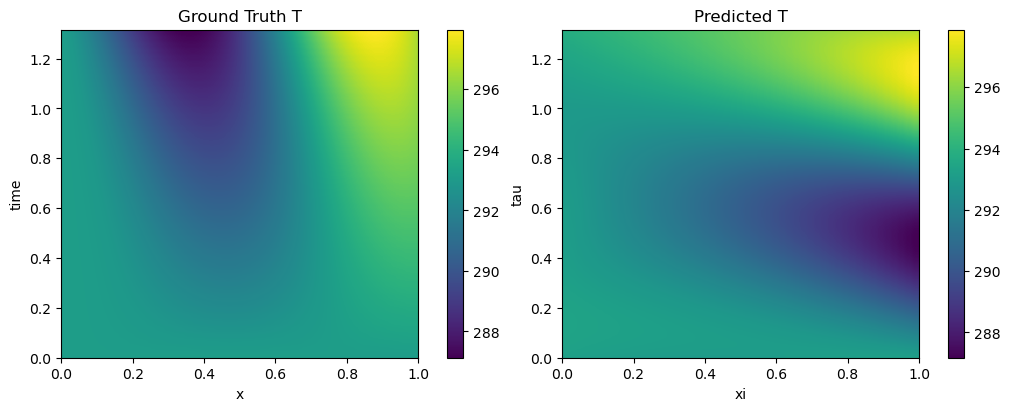

In [ ]:
# Quick comparison plot (ground truth vs prediction)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

im0 = axes[0].imshow(T, aspect='auto', origin='lower',
                  extent=[xi.min(), xi.max(), tau.min(), tau.max()])
axes[0].set_title('Ground Truth T')
axes[0].set_xlabel('xi')
axes[0].set_ylabel('time')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(T_pred, aspect='auto', origin='lower',
                  extent=[xi.min(), xi.max(), tau.min(), tau.max()])
axes[1].set_title('Predicted T')
axes[1].set_xlabel('xi')
axes[1].set_ylabel('tau')
plt.colorbar(im1, ax=axes[1])

plt.show()


Loaded checkpoint: c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\models\checkpoints\run\best.pt
Validation logs:
  total: 2.0852e-03
  pde: 1.2306e-03
  ic: 1.4827e-04
  bc: 4.3177e-04
  data: 2.7455e-04
  smooth: 0.0000e+00
Validation RMSE (data): 1.6570e-02


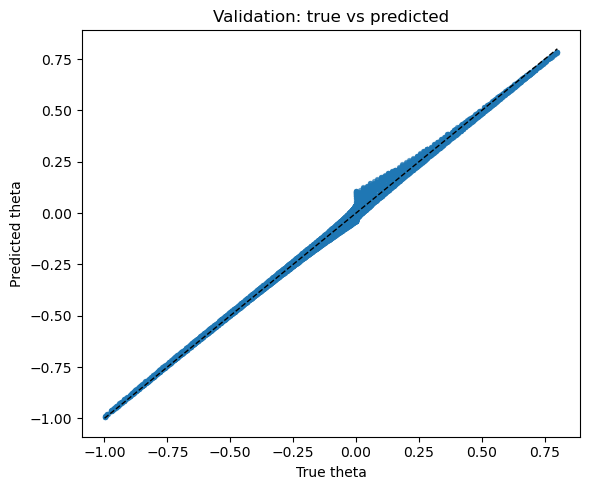

In [39]:
# Reload train module to pick up recent edits (avoids ImportError from stale imports)
import src.train as train_mod
importlib.reload(train_mod)
from src.train import compute_losses_eval

# Load best checkpoint if available (prefer LBFGS-refined checkpoint)
ckpt = None
for name in ("best_lbfgs_path", "best_path"):
    if name in globals() and globals()[name] is not None:
        ckpt = globals()[name]
        break

if ckpt is not None and ckpt.exists():
    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state["state_dict"])
    model.to(device)
    print(f"Loaded checkpoint: {ckpt}")
else:
    print("No checkpoint found; using current in-memory model")

# Evaluate losses (keeps autograd enabled as required by PINN residuals)
val_loss, val_logs = compute_losses_eval(model, val_batch, weights, flux_mode=flux_mode, flux_cfg=flux_cfg)
print("Validation logs:")
for k, v in val_logs.items():
    print(f"  {k}: {v:.4e}")

wall_clock_time_s = float(time.time() - logger._start_time) if logger._start_time else ""
convergence_flag = "ok" if all(math.isfinite(float(val_logs.get(k, float("nan")))) for k in ("total","pde","ic","bc","data")) else "nan"

final_metrics = {
    "experiment_id": experiment_id,
    "wall_clock_time_s": wall_clock_time_s,
    "convergence_flag": convergence_flag,
    "final_total_loss": float(val_logs.get("total", math.nan)),
    "final_pde_loss": float(val_logs.get("pde", math.nan)),
    "final_bc_loss": float(val_logs.get("bc", math.nan)),
    "final_ic_loss": float(val_logs.get("ic", math.nan)),
    "final_data_loss": float(val_logs.get("data", math.nan)),
    "final_grad_norm": "",  # not available without extra grads
    "l2_error_temperature": "",
    "max_abs_error": "",
    "relative_l2_error": "",
    "r2_score": "",
}
logger.end_run(final_metrics)

# If interior validation data exists, compute predictions and show RMSE + scatter
rmse = float("nan")
if getattr(val_batch, "xi_data", None) is not None and getattr(val_batch, "theta_data", None) is not None:
    model.eval()
    with torch.no_grad():
        X_val = torch.cat([val_batch.xi_data, val_batch.tau_data], dim=1).to(device)
        y_true = val_batch.theta_data.to(device)
        y_pred = model(X_val)

    mse = torch.mean((y_pred - y_true) ** 2).item()
    rmse = mse ** 0.5
    print(f"Validation RMSE (data): {rmse:.4e}")

    plt.figure(figsize=(6, 5))
    plt.scatter(y_true.cpu().numpy(), y_pred.detach().cpu().numpy(), s=8, alpha=0.6)
    mn = min(y_true.min().item(), y_pred.min().item())
    mx = max(y_true.max().item(), y_pred.max().item())
    plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    plt.xlabel("True theta")
    plt.ylabel("Predicted theta")
    plt.title("Validation: true vs predicted")
    plt.tight_layout()
    plt.show()
else:
    print("No interior validation data present in `val_batch` to plot.")


## Upload and update

In [40]:
# Architecture experiment logger
results_csv = ROOT / "results" / "arch_search.csv"
ensure_arch_search_csv(str(results_csv))
baseline_best = load_best_arch_result(str(results_csv), metric="val_rmse_data")

def _safe_git_commit() -> str:
    try:
        out = subprocess.run(
            ["git", "rev-parse", "--short", "HEAD"],
            cwd=ROOT,
            capture_output=True,
            text=True,
            check=True,
        )
        return out.stdout.strip()
    except Exception:
        return ""

def _first_linear(module):
    for m in module.modules():
        if isinstance(m, torch.nn.Linear):
            return m
    return None

def _activation_name(module):
    for m in module.modules():
        if isinstance(m, (torch.nn.Tanh, torch.nn.ReLU, torch.nn.GELU, torch.nn.Sigmoid, torch.nn.SiLU, torch.nn.ELU, torch.nn.LeakyReLU)):
            return m.__class__.__name__.lower()
    return "unknown"

first_linear = _first_linear(model)
n_neurons = int(first_linear.out_features) if first_linear is not None else None
n_linear = sum(1 for m in model.modules() if isinstance(m, torch.nn.Linear))
n_hidden_layers = max(n_linear - 1, 0)

adam_steps = int(globals().get("N_EPOCHS", globals().get("steps", 1000)))
lbfgs_iters = int(globals().get("max_iter", 500)) if "best_lbfgs_path" in globals() else 0
optimizer_name = "adam+lbfgs" if "best_lbfgs_path" in globals() else "adam"

current_result = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "git_commit": _safe_git_commit(),
    "seed": 42,
    "n_layers": n_hidden_layers,
    "n_neurons": n_neurons,
    "activation": _activation_name(model),
    "optimizer": optimizer_name,
    "epochs": adam_steps + lbfgs_iters,
    "lr": 1e-3,
    "n_colloc": int(globals().get("n_r", 50000)),
    "n_boundary": int(getattr(train_batch, "xi_bc", torch.empty(0, 1)).shape[0]),
    "n_initial": int(getattr(train_batch, "xi_ic", torch.empty(0, 1)).shape[0]),
    "n_data": int(getattr(train_batch, "xi_data", torch.empty(0, 1)).shape[0]),
    "loss_total": float(val_logs.get("total", math.nan)),
    "loss_pde": float(val_logs.get("pde", math.nan)),
    "loss_ic": float(val_logs.get("ic", math.nan)),
    "loss_bc": float(val_logs.get("bc", math.nan)),
    "loss_data": float(val_logs.get("data", math.nan)),
    "val_rmse_data": float(rmse),
    "val_pde_loss": float(val_logs.get("pde", math.nan)),
}

improved, reason = compare_arch_to_best(current_result, baseline_best)
append_arch_search_result(str(results_csv), current_result)

def _fmt(x):
    try:
        v = float(x)
        if math.isfinite(v):
            return f"{v:.6e}"
    except Exception:
        pass
    return "nan"

print()
print("Architecture comparison:")
if baseline_best is None:
    print("Baseline best metrics: none (first recorded run)")
else:
    print(
        "Baseline best metrics: "
        f"val_rmse_data={_fmt(baseline_best.get('val_rmse_data'))}, "
        f"val_pde_loss={_fmt(baseline_best.get('val_pde_loss'))}, "
        f"loss_total={_fmt(baseline_best.get('loss_total'))}"
    )

print(
    "Current metrics: "
    f"val_rmse_data={_fmt(current_result.get('val_rmse_data'))}, "
    f"val_pde_loss={_fmt(current_result.get('val_pde_loss'))}, "
    f"loss_total={_fmt(current_result.get('loss_total'))}"
)
print(("? IMPROVED: " if improved else "? NOT IMPROVED: ") + reason)
print(f"Logged run to {results_csv}")




Architecture comparison:
Baseline best metrics: val_rmse_data=4.817587e-03, val_pde_loss=3.772722e-04, loss_total=2.666410e-03
Current metrics: val_rmse_data=1.656956e-02, val_pde_loss=1.230572e-03, loss_total=2.085160e-03
? NOT IMPROVED: RMSE gain -1.175197e-02 is below threshold 1.000000e-04.
Logged run to c:\Users\wscm13\OneDrive - Loughborough University\Part C\IDP\Individual Project\PINN\results\arch_search.csv


In [41]:
log_path = Path(ROOT, "results", "experiment_log.csv")
if log_path.exists():
    log_df = pd.read_csv(log_path)
    display(log_df.tail(5))
else:
    print(f"No log found at {log_path}")


,experiment_id,date_time_utc,commit_hash,python_version,torch_version,cuda_available,device,random_seed,case_id,data_paths,...,final_total_loss,final_pde_loss,final_bc_loss,final_ic_loss,final_data_loss,final_grad_norm,l2_error_temperature,max_abs_error,relative_l2_error,r2_score
0,20260216T153205Z_const_5000_596ff96_19ff91,2026-02-16T15:32:05.004343+00:00,596ff96,3.10.9,1.12.1,False,cpu,42,const_5000,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.001084,0.000171,0.000001,0.000576,0.000336,NaN,NaN,NaN,NaN,NaN
1,20260216T161524Z_const_5000_775133c_437d6a,2026-02-16T16:15:24.247973+00:00,775133c,3.10.9,1.12.1,False,cpu,42,const_5000,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002162,0.000349,0.000325,0.001451,0.000037,NaN,NaN,NaN,NaN,NaN
2,20260309T145841Z_sine_A10000_T50_unknown_7eaa2a,2026-03-09T14:58:41.916964+00:00,unknown,3.10.9,1.12.1,False,cpu,42,sine_A10000_T50,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002085,0.001231,0.000432,0.000148,0.000275,NaN,NaN,NaN,NaN,NaN
3,20260309T145841Z_sine_A10000_T50_unknown_7eaa2a,2026-03-09T14:58:41.916964+00:00,unknown,3.10.9,1.12.1,False,cpu,42,sine_A10000_T50,manifest=c:\Users\wscm13\OneDrive - Loughborou...,...,0.002085,0.001231,0.000432,0.000148,0.000275,NaN,NaN,NaN,NaN,NaN
